Name: Suvidya Sonawane  
Division: C  
Roll no. 48

#### Title:- Build a Multiclass classifier using the CNN model. Use MNIST or any other suitable dataset.   
a) Perform Data Pre-processing  
b) Define Model and perform training  
c) Evaluate Results using confusion matrix.  
Objective:  
Building a multiclass classifier using a Convolutional Neural Network (CNN) using MNIST or 
any other suitable dataset. It involves several steps, including data pre-processing, defining the  
model architecture, training the model, and evaluating its performance using a confusion 
matrix.  
Outcome:  
Implement the technique of Convolution neural network (CNN)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

In [14]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


## 2. DATA PREPROCESSING

In [15]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape (for CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

### 3. DATA VISUALIZATION

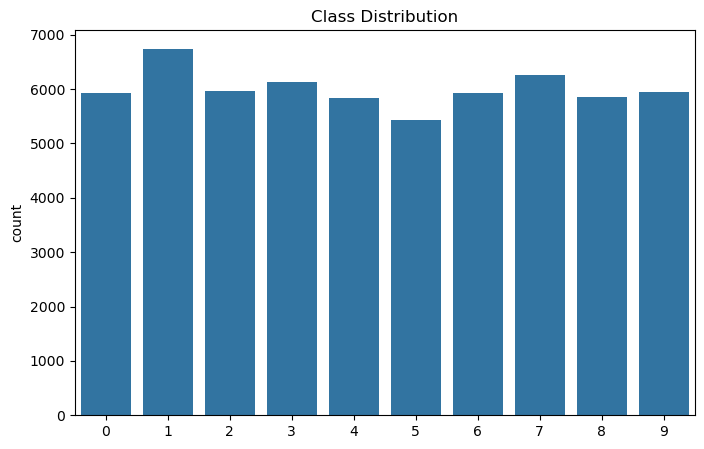

In [16]:
# Class distribution
plt.figure(figsize=(8,5))
sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.show()

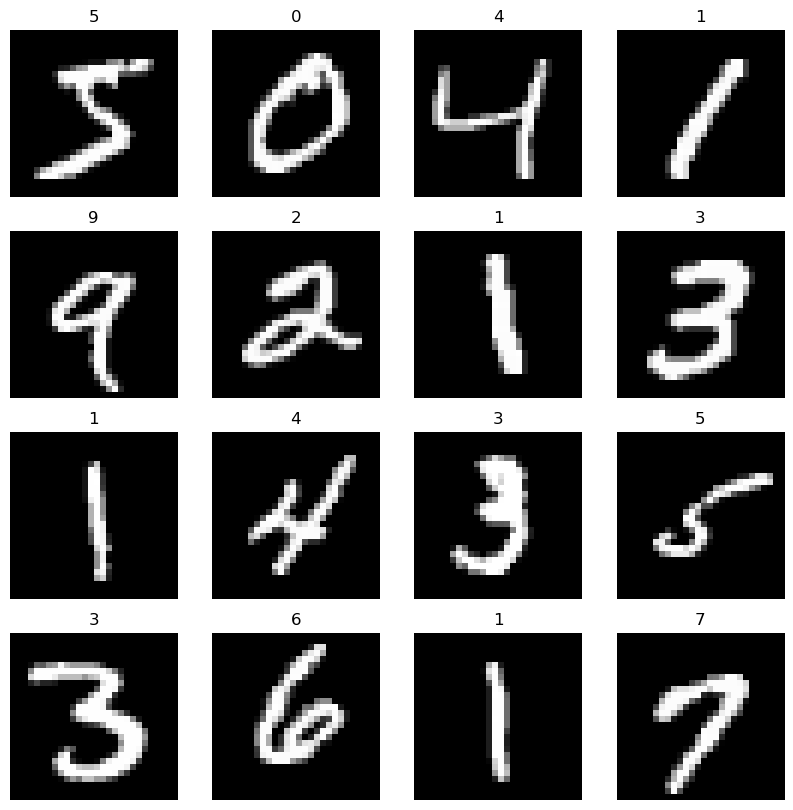

In [17]:
# Sample images
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

## 4. BUILD CNN MODEL

In [18]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

C:\Users\sonal\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 5. COMPILE MODEL

In [19]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## 6. TRAIN MODEL

In [20]:
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 104s 52ms/step - accuracy: 0.8675 - loss: 0.4153 - val_accuracy: 0.9858 - val_loss: 0.0446
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 106s 56ms/step - accuracy: 0.9751 - loss: 0.0817 - val_accuracy: 0.9888 - val_loss: 0.0313
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 40ms/step - accuracy: 0.9831 - loss: 0.0578 - val_accuracy: 0.9894 - val_loss: 0.0315
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.9863 - loss: 0.0452 - val_accuracy: 0.9899 - val_loss: 0.0292
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.9888 - loss: 0.0376 - val_accuracy: 0.9910 - val_loss: 0.0297
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9911 - loss: 0.0305 - val_accuracy: 0.9921 - val_loss: 0.0266
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.9912 - loss: 0.0272 - val_accuracy: 0.9915 - val_loss: 0.0264
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9915

## 7. EVALUATE MODEL

In [21]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9894 - loss: 0.0380
Test Accuracy: 0.9922000169754028


## 8. PREDICTIONS

In [22]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


## 9. CONFUSION MATRIX

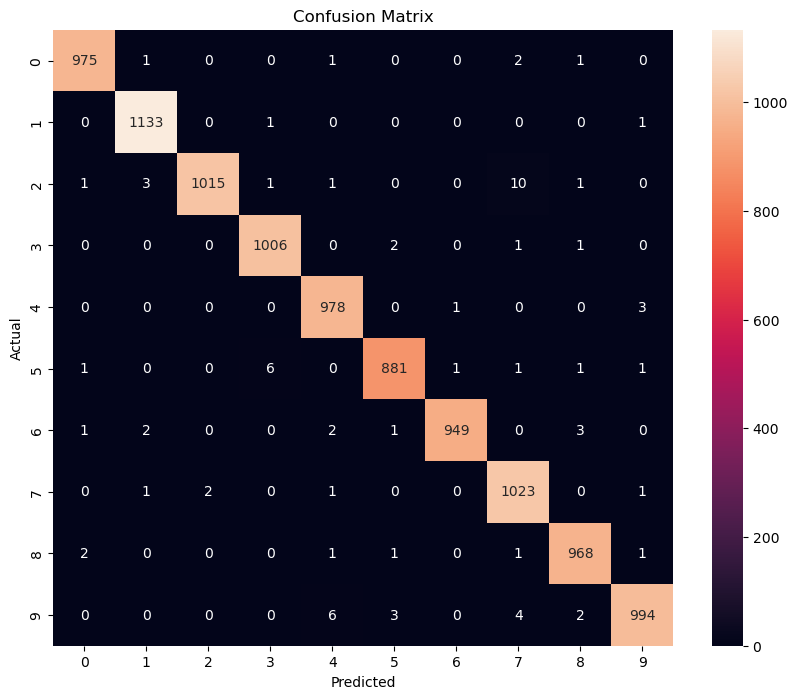

In [23]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 10. CLASSIFICATION REPORT

In [24]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.98      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 11. ACCURACY GRAPH

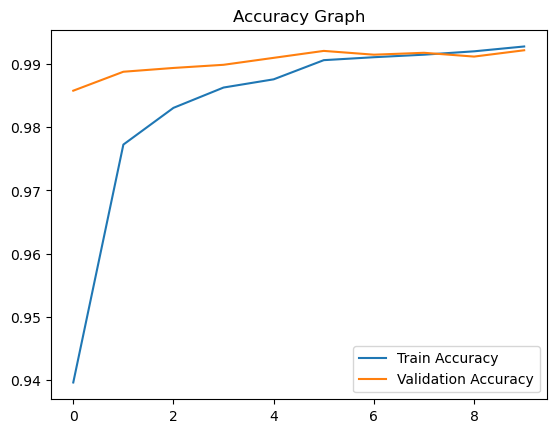

In [25]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

## 12. LOSS GRAPH

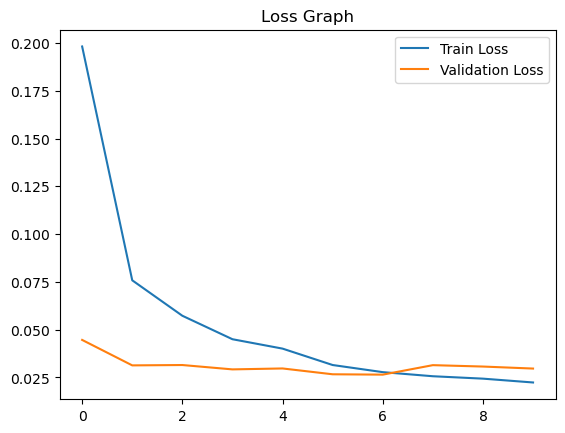

In [26]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

## 13. MISCLASSIFIED IMAGES

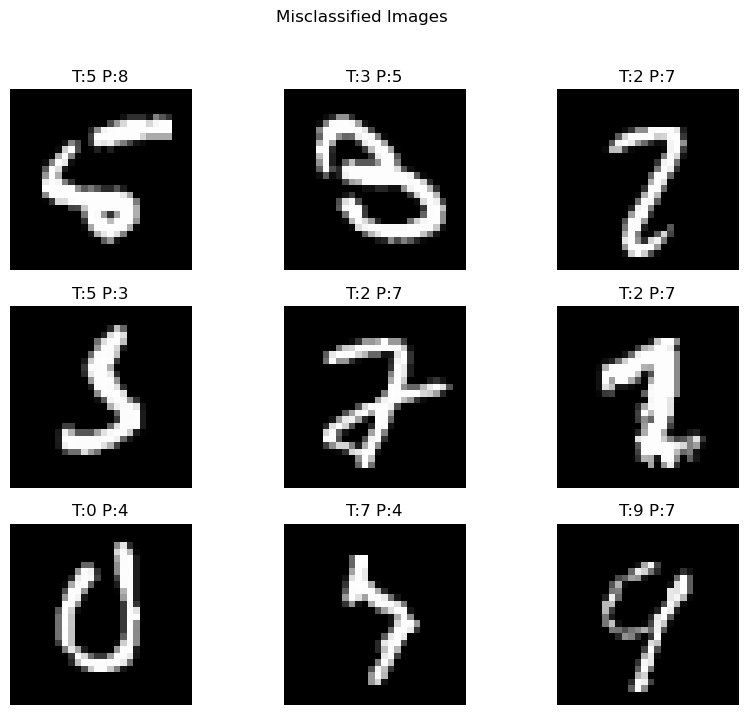

In [27]:
misclassified = np.where(y_test != y_pred_classes)[0]

plt.figure(figsize=(10,8))
for i, index in enumerate(misclassified[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[index].reshape(28,28), cmap='gray')
    plt.title(f"T:{y_test[index]} P:{y_pred_classes[index]}")
    plt.axis('off')
plt.suptitle("Misclassified Images")
plt.show()

## 14. CORRECT PREDICTIONS

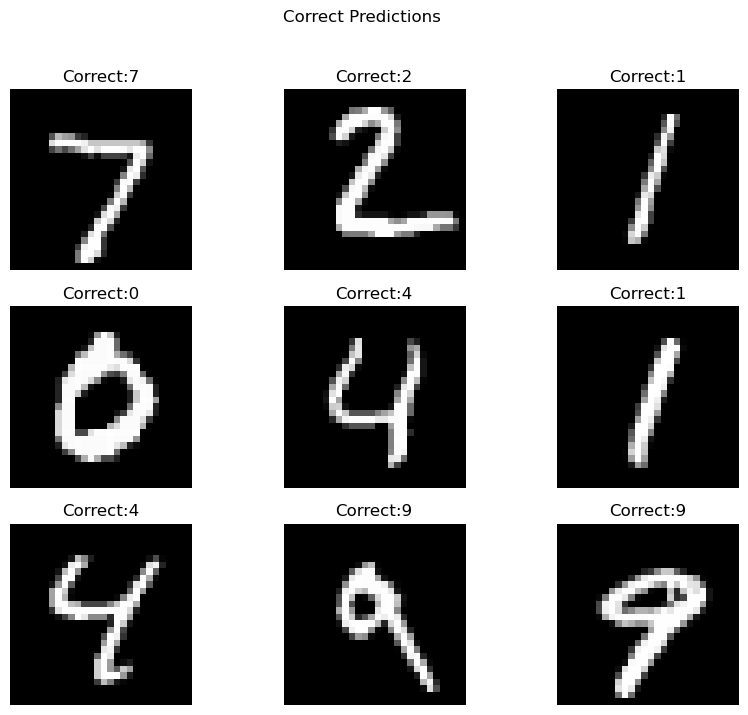

In [28]:
correct = np.where(y_test == y_pred_classes)[0]

plt.figure(figsize=(10,8))
for i, index in enumerate(correct[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[index].reshape(28,28), cmap='gray')
    plt.title(f"Correct:{y_pred_classes[index]}")
    plt.axis('off')
plt.suptitle("Correct Predictions")
plt.show()

## 15. PREDICTION CONFIDENCE

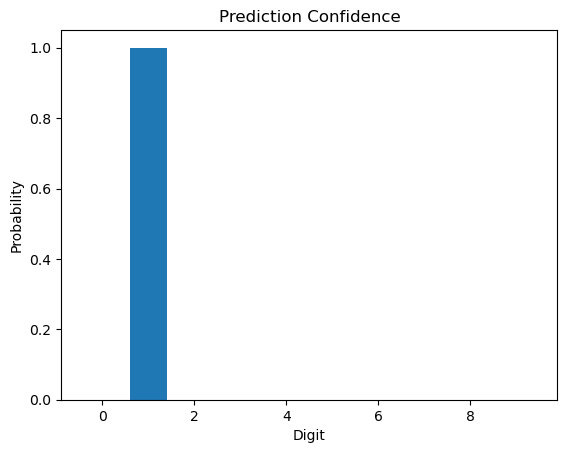

In [29]:
plt.figure()
sample = 5
plt.bar(range(10), y_pred[sample])
plt.title("Prediction Confidence")
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.show()

## 16. FEATURE MAP VISUALIZATION

In [30]:
layer_outputs = [layer.output for layer in model.layers[:2]]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

sample_image = X_test[0].reshape(1,28,28,1)
activations = activation_model.predict(sample_image)

plt.figure(figsize=(10,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(activations[0][0, :, :, i], cmap='gray')
    plt.axis('off')
plt.suptitle("Feature Maps")
plt.show()

AttributeError: The layer sequential_1 has never been called and thus has no defined input.